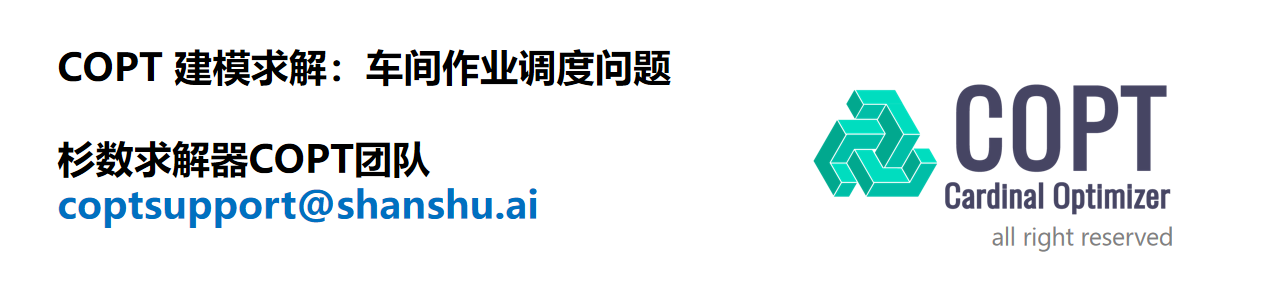

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

# 车间作业调度问题代码实现
## 使用COPT建模求解车间作业调度问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **添加模型数据**

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $C_{j,k} \in \mathbb{R}^+$：连续变量，表示作业 $j$ 在阶段 $k$ 的完工时间节点。
        - $x_{i,j,k} \in \{0,1\}$：0-1 变量，表示作业在机器上的排他排序。若作业 $i$ 在阶段 $k$ 的加工排在作业 $j$ 之前，则取 1，否则取 0。
        - $C_{max} \in \mathbb{R}^+$：连续变量，表示整批所有作业的最大完工时间。
    - **目标函数**：
        - 最小化所有作业完成的最晚时间：$ \min  C_{max} $
    - **约束条件**：
        - **初始阶段逻辑合理性约束**
        - **阶段加工顺序约束**
        - **排序互斥约束（大M法）**
        - **最大完工时间约束**

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import random

## 添加模型数据

In [6]:
# 数据
jobs = [0, 1, 2]
stages = [0, 1, 2]
Proc_time = [
    [3, 2, 4],
    [2, 5, 1],
    [4, 3, 2],
]
M =1e4  # 足够大的常数

## 创建COPT求解环境和模型

In [8]:
# 初始化模型
env = cp.Envr()
model = env.createModel("multi_stage_schedule")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素
### 添加决策变量

- $C_{j,k} \in \mathbb{R}^+$：连续变量，表示作业 $j$ 在阶段 $k$ 的完工时间节点。
- $x_{i,j,k} \in \{0,1\}$：0-1 变量，表示作业在机器上的排他排序。若作业 $i$ 在阶段 $k$ 的加工排在作业 $j$ 之前，则取 1，否则取 0。
- $C_{max} \in \mathbb{R}^+$：连续变量，表示整批所有作业的最大完工时间。

In [10]:
# 定义变量：完工时间
C = {}
for j in jobs:
    for k in stages:
        C[j, k] = model.addVar(name=f"C_{j}_{k}")

In [11]:
# 定义变量：优先顺序
x = {}
for k in stages:
    for i, j in combinations(jobs, 2):
        x[i, j, k] = model.addVar(vtype=COPT.BINARY, name=f"x_{i}_{j}_{k}")
        x[j, i, k] = model.addVar(vtype=COPT.BINARY, name=f"x_{j}_{i}_{k}")

In [12]:
# makespan
C_max = model.addVar(name="C_max")

### 设置目标函数

最小化所有作业完成的最大完工时间（Makespan）：
$$ \min  C_{max} $$

In [14]:
model.setObjective(C_max, sense=COPT.MINIMIZE)

### 添加约束条件
1. **初始阶段逻辑合理性约束**：要求所有作业在初始阶段的完工时间必须大于或等于其在该阶段的加工时长，以此作为时间轴的自然物理起点。
$$ C_{j,0} \ge Proc\_time_{j,0}, \quad \forall j \in J $$

In [16]:
# 逻辑合理性约束：规定初始阶段的完工时间下限为其加工时间
for j in jobs:
    model.addConstr(C[j, 0] >= Proc_time[j][0])  

2. **阶段加工顺序约束**：每个作业必须按照阶段流程顺序加工，前一个阶段完成了，后一个阶段才能开始。即作业$j$在当前阶段$k$的完工时间，必须大于或等于其在前一阶段$k-1$的完工时间与当前阶段加工时长之和，确保工序间不发生时间重叠与逻辑倒置。
$$ C_{j,k} \ge C_{j,k-1} + Proc\_time_{j,k}, \quad \forall j \in J, k = 1, 2 $$

In [18]:
# 阶段加工顺序约束
for j in jobs:
    for k in range(1, len(stages)):
        model.addConstr(C[j, k] >= C[j, k-1] + Proc_time[j][k])

3. **排序互斥约束（大M法）**：在任意阶段$k$，同一台机器同一时刻只能加工一个作业。对于任意两个不同的作业$i$与$j$（$i \neq j$），在同一阶段 k 上：
$$ C_{i,k} \ge C_{j,k} + Proc\_time_{i,k} - M ·(1 - x_{i,j,k}), \quad \forall i, j \in J, k \in K, i\neq j $$
$$ C_{j,k} \ge C_{i,k} + Proc\_time_{j,k} - M · x_{i,j,k}, \quad \forall i, j \in J, k \in K, i\neq j $$
$$ x_{i,j,k} + x_{j,i,k} = 1, \quad \forall i, j \in J $$

**大M法：控制约束的启用/禁用。**

- $x_{i,j,k} = 1$ → $j$ 在 $i$ 前 → $j$ 的加工结束后 $i$ 才能开始。
- $x{_i,j,k} = 0$ → $i$ 在 $j$ 前 → 相反的方向起作用。
- 最后一行 $ x_{i,j,k} + x_{j,i,k} = 1$ 确保两者顺序明确、有且只能有一个取值为1。

In [21]:
# 排他顺序约束
for k in stages:
    for i, j in combinations(jobs, 2):
        model.addConstr(C[i, k] >= C[j, k] + Proc_time[i][k] - M * (1 - x[i, j, k]))
        model.addConstr(C[j, k] >= C[i, k] + Proc_time[j][k] - M * x[i, j, k])
        model.addConstr(x[i, j, k] + x[j, i, k] == 1)

4. **最大完工时间约束**：所有作业的最大完工时间必须大于或等于所有作业在最后阶段的完成时间。
$$ C_{max} \ge C_{j, 2}, \quad \forall j \in J $$

In [23]:
# 最大完工时间约束
for j in jobs:
    model.addConstr(C_max >= C[j, stages[-1]]) # C[j, stages[-1]] 表示作业j的最后阶段的完成时间

## 求解

In [25]:
model.solve()

Model fingerprint: ac288e

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    39 rows, 28 columns and 93 non-zero elements
    18 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    27 rows, 19 columns and 72 non-zero elements
    9 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+04]
    Range of rhs coefficients:       [1e+00,1e+04]
    Range of bound coefficients:     [1e+00,1e+01]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     5.3%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.200000e+01            --     Inf  0.02s
H        0         1      --       0  1.2000

## 获取结果

In [27]:
# 获取结果
if model.status == COPT.OPTIMAL:
    print("\n最优 makespan:", f"{C_max.X}\n")
    for j in jobs:
        for k in stages:
            val = C[j, k].X
            print(f"Job {j}, Stage {k} 完成时间: {val}")


最优 makespan: 15.0

Job 0, Stage 0 完成时间: 3.0
Job 0, Stage 1 完成时间: 5.0
Job 0, Stage 2 完成时间: 9.0
Job 1, Stage 0 完成时间: 5.0
Job 1, Stage 1 完成时间: 10.0
Job 1, Stage 2 完成时间: 11.0
Job 2, Stage 0 完成时间: 9.0
Job 2, Stage 1 完成时间: 13.0
Job 2, Stage 2 完成时间: 15.0


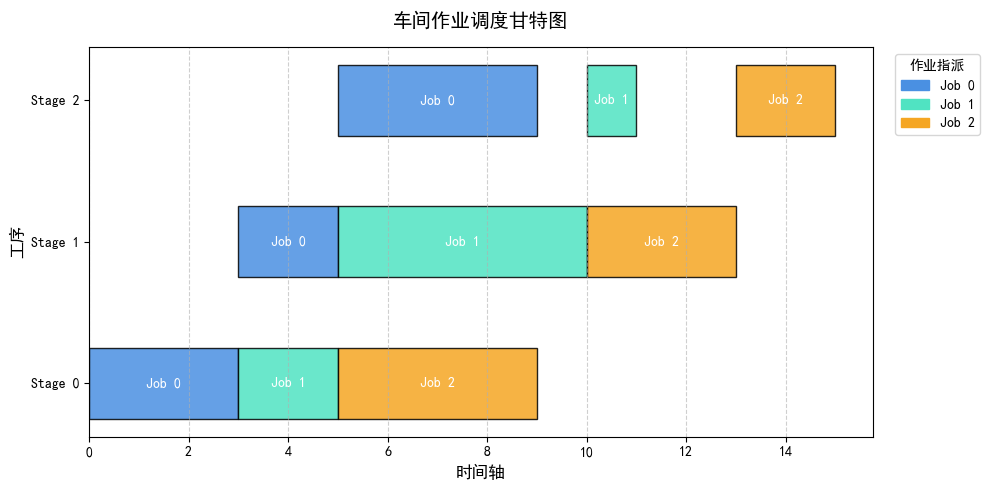

In [28]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

if model.status == COPT.OPTIMAL:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#4A90E2', '#50E3C2', '#F5A623'] 
    
    # 解析数据并绘图
    for j in jobs:
        for k in stages:
            end_time = C[j, k].X
            duration = Proc_time[j][k]
            start_time = end_time - duration
            
            # 绘制水平条形图作为甘特图的横序
            ax.barh(y=f"Stage {k}", width=duration, left=start_time, 
                    color=colors[j], edgecolor='black', height=0.5, alpha=0.85)
            
            # 在条形图中间添加作业标签
            ax.text(start_time + duration / 2, f"Stage {k}", f"Job {j}", 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # 图表细节设置
    ax.set_xlabel('时间轴', fontsize=12, fontweight='bold')
    ax.set_ylabel('工序', fontsize=12, fontweight='bold')
    ax.set_title('车间作业调度甘特图', fontsize=14, fontweight='bold', pad=15)
    
    # 添加图例
    patches = [mpatches.Patch(color=colors[j], label=f'Job {j}') for j in jobs]
    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', title="作业指派")
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

模型通过全局统筹不仅锁定了理论的最短生产交付周期，更揭示了产能瓶颈在多道工序间的动态平衡规律。在严格的设备排他性与工序耦合约束下，该全局调度方案实现了关键设备空闲等待时间的极限压缩与上下游生产工序的精准对齐，避免了资源挤占与车间半成品的无端积压，为现代制造企业向精益化、自动化转型提供了量化决策支撑。